# Unit 3 — Mixture models and EM

The practice questions of this unit (21CSC305P). Every question below is self-contained: run any cell on its own. All questions use the Seattle daily weather data (`website/data/seattle_weather.csv`). Run the first cell before the others.

In [1]:
%config InlineBackend.figure_format = "svg"
import os
import sys
sys.path.insert(0, "website")          # plot style lives in website/weather.py
from weather import use_style
use_style()
if os.path.basename(os.getcwd()) != "website":
    os.chdir("website")                # so the programs find data/seattle_weather.csv

## Practice 1 — Implement K-means clustering, mixtures of Gaussians and Hierarchical clustering algorithm to categorize data

Group the days into 4 clusters without using the weather labels. K-means puts each day in the cluster with the nearest centre. A Gaussian mixture (fitted with EM) gives each day a probability for every cluster. Hierarchical clustering starts with every day alone and keeps joining the two closest groups.

Days in each cluster:
K-means:      [620, 449, 98, 294]
GMM:          [838, 278, 194, 151]
Hierarchical: [190, 293, 433, 545]

GMM probabilities for the first 5 days:
[[1.   0.   0.   0.  ]
 [0.   0.34 0.   0.66]
 [0.   0.07 0.91 0.01]
 [0.   0.   0.   1.  ]
 [0.   0.85 0.04 0.1 ]]

Average of each K-means cluster:
        precipitation  temp_max  temp_min  wind
kmeans                                         
0                 0.6      23.4      12.7   2.8
1                 1.7      10.5       3.6   2.3
2                23.5      13.3       8.1   4.5
3                 3.5      11.9       5.9   5.2


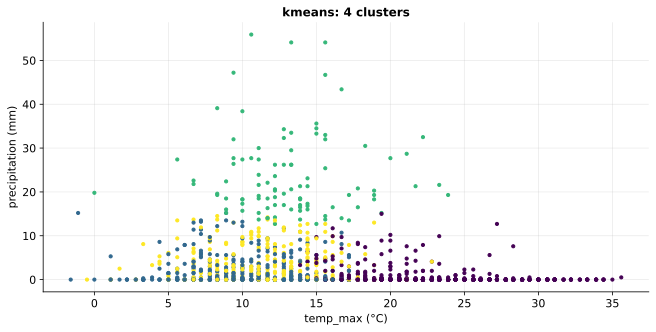

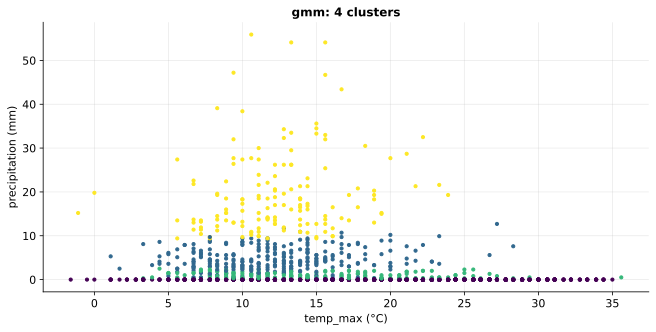

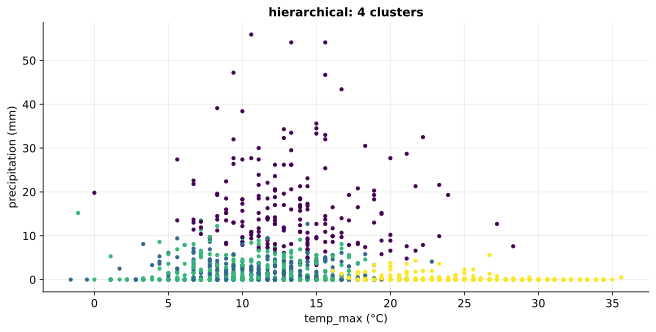

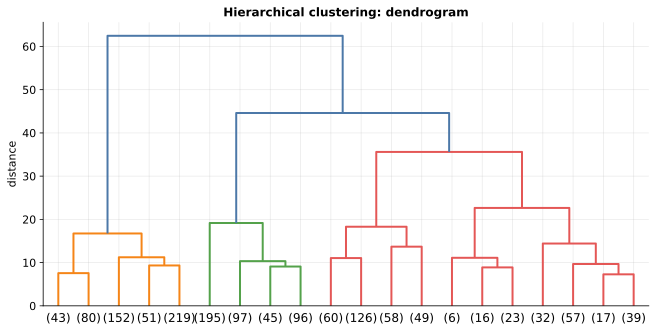

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import linkage, dendrogram

df = pd.read_csv("data/seattle_weather.csv")
columns = ["precipitation", "temp_max", "temp_min", "wind"]

# Put every column on the same scale (mean 0, std 1)
X = StandardScaler().fit_transform(df[columns])

# 1. K-means
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
df["kmeans"] = kmeans.fit_predict(X)

# 2. Mixture of Gaussians (trained with the EM algorithm)
gmm = GaussianMixture(n_components=4, random_state=42)
df["gmm"] = gmm.fit_predict(X)

# 3. Hierarchical clustering (Ward: join the groups that grow the least)
hierarchical = AgglomerativeClustering(n_clusters=4, linkage="ward")
df["hierarchical"] = hierarchical.fit_predict(X)

print("Days in each cluster:")
print("K-means:     ", df["kmeans"].value_counts().sort_index().tolist())
print("GMM:         ", df["gmm"].value_counts().sort_index().tolist())
print("Hierarchical:", df["hierarchical"].value_counts().sort_index().tolist())
print()

# The GMM gives soft answers: a probability for every cluster
print("GMM probabilities for the first 5 days:")
print(gmm.predict_proba(X[:5]).round(2))
print()

# What a typical day in each K-means cluster looks like
print("Average of each K-means cluster:")
print(df.groupby("kmeans")[columns].mean().round(1))

# Plots 1-3: the clusters found by each method
for method in ["kmeans", "gmm", "hierarchical"]:
    plt.figure(figsize=(9, 4.5))
    plt.scatter(df["temp_max"], df["precipitation"], c=df[method], cmap="viridis", s=10)
    plt.xlabel("temp_max (°C)")
    plt.ylabel("precipitation (mm)")
    plt.title(method + ": 4 clusters")
    plt.show()

# Plot 4: dendrogram (the tree of joins, last 20 shown)
# scikit-learn cannot draw it, so scipy builds the same Ward tree for the picture
tree = linkage(X, method="ward")
plt.figure(figsize=(9, 4.5))
dendrogram(tree, truncate_mode="lastp", p=20)
plt.title("Hierarchical clustering: dendrogram")
plt.ylabel("distance")
plt.show()

## Practice 2 — Create a program to perform PCA

Principal component analysis (PCA) finds new axes, called components, along which the data changes the most. The first two components keep most of the information, so every day can be drawn as a point on a 2-D plot.

Variance explained by each component: [0.497 0.307 0.168 0.027]
Kept by the first two components: 80.4 %

How each component mixes the original columns:
     precipitation  temp_max  temp_min  wind
PC1          -0.29      0.67      0.63 -0.25
PC2           0.64      0.20      0.34  0.66
PC3          -0.71      0.02     -0.06  0.71
PC4           0.12      0.71     -0.69  0.03


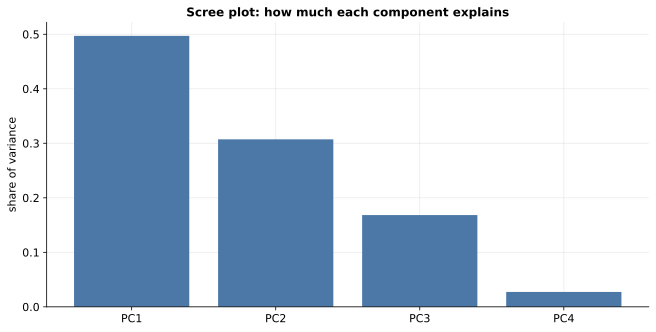

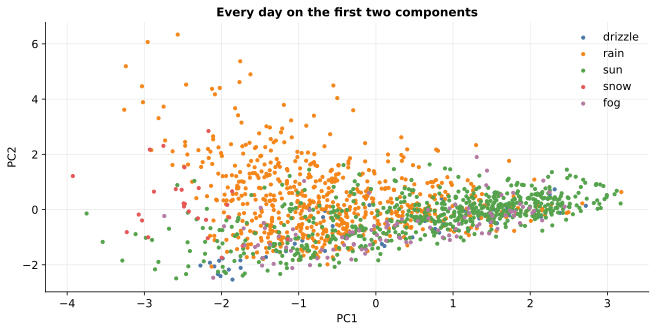

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv("data/seattle_weather.csv")
columns = ["precipitation", "temp_max", "temp_min", "wind"]

# Put every column on the same scale (mean 0, std 1)
X = StandardScaler().fit_transform(df[columns])

# PCA: 4 columns become 4 components, sorted from most to least important
pca = PCA()
X_pca = pca.fit_transform(X)

print("Variance explained by each component:", pca.explained_variance_ratio_.round(3))
print("Kept by the first two components:", round(pca.explained_variance_ratio_[:2].sum() * 100, 1), "%")
print()
print("How each component mixes the original columns:")
print(pd.DataFrame(pca.components_, columns=columns, index=["PC1", "PC2", "PC3", "PC4"]).round(2))

# Plot 1: scree plot
plt.figure(figsize=(9, 4.5))
plt.bar(["PC1", "PC2", "PC3", "PC4"], pca.explained_variance_ratio_)
plt.ylabel("share of variance")
plt.title("Scree plot: how much each component explains")
plt.show()

# Plot 2: every day on the first two components, coloured by weather type
df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]
plt.figure(figsize=(9, 4.5))
for weather in df["weather"].unique():
    days = df[df["weather"] == weather]
    plt.scatter(days["PC1"], days["PC2"], s=10, label=weather)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Every day on the first two components")
plt.legend()
plt.show()